## 1. Import Libraries and Load Data

In [1]:
# Add project root to path and import config
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent.parent))
from config import (
    FIRES_MERGED_SUPERVISED, 
    FIRES_ENGINEERED_SUPERVISED, 
    SELECTED_FEATURES_SUPERVISED, 
    FEATURE_IMPORTANCE_SUPERVISED
)

# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif, chi2, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Set plotting style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("✅ Config and libraries imported")
print(f"   Input: {FIRES_MERGED_SUPERVISED}")
print(f"   Output: {FIRES_ENGINEERED_SUPERVISED}")

✅ Config and libraries imported
   Input: C:\Users\Azur\Downloads\TP\DM\results\intermediate\supervised\fires_merged_all_features.csv
   Output: C:\Users\Azur\Downloads\TP\DM\results\features\supervised\fires_engineered_features.csv


In [2]:
# Load the merged dataset for supervised learning
df = pd.read_csv(FIRES_MERGED_SUPERVISED)

print(f"Dataset shape: {df.shape}")
print(f"\nDataset columns ({len(df.columns)}):")
print(df.columns.tolist())

# Check if TEXTURE_SOTER was already one-hot encoded in soil.ipynb
texture_soter_cols = [col for col in df.columns if col.startswith('TEXTURE_SOTER')]
if texture_soter_cols:
    print(f"\n✅ TEXTURE_SOTER encoding detected:")
    for col in texture_soter_cols:
        if col == 'TEXTURE_SOTER':
            print(f"  - {col}: categorical (should be encoded in soil.ipynb)")
        else:
            print(f"  - {col}: binary encoded")
else:
    print("\n⚠ No TEXTURE_SOTER columns found")

print(f"\n📊 Dataset Preview:")
print(df.head())

Dataset shape: (6570, 44)

Dataset columns (44):
['longitude', 'latitude', 'class', 'prec_winter', 'tmax_winter', 'tmin_winter', 'prec_spring', 'tmax_spring', 'tmin_spring', 'prec_summer', 'tmax_summer', 'tmin_summer', 'prec_autumn', 'tmax_autumn', 'tmin_autumn', 'elevation', 'slope', 'aspect', 'roughness', 'soil_unit_id', 'COARSE', 'SAND', 'SILT', 'CLAY', 'TEXTURE_USDA', 'BULK', 'REF_BULK', 'ORG_CARBON', 'PH_WATER', 'TOTAL_N', 'CN_RATIO', 'CEC_SOIL', 'CEC_CLAY', 'CEC_EFF', 'TEB', 'BSAT', 'ALUM_SAT', 'ESP', 'TCARBON_EQ', 'GYPSUM', 'ELEC_COND', 'TEXTURE_SOTER_F', 'TEXTURE_SOTER_M', 'TEXTURE_SOTER_V']

✅ TEXTURE_SOTER encoding detected:
  - TEXTURE_SOTER_F: binary encoded
  - TEXTURE_SOTER_M: binary encoded
  - TEXTURE_SOTER_V: binary encoded

📊 Dataset Preview:
   longitude  latitude  class  prec_winter  tmax_winter  tmin_winter  \
0    9.23018  35.09261      0    -0.655354     0.630360     0.574852   
1    5.60547  33.50662      0    -1.068579     1.115258     0.531323   
2   11.11005 

## 2. Feature Extraction

Create new features from existing ones to capture domain knowledge and improve predictive power.

### 2.1 Climate-Based Features

In [3]:
# Create a copy for feature engineering
df_engineered = df.copy()

# Temperature features
# Annual temperature range (max - min across all seasons)
temp_max_cols = ['tmax_winter', 'tmax_spring', 'tmax_summer', 'tmax_autumn']
temp_min_cols = ['tmin_winter', 'tmin_spring', 'tmin_summer', 'tmin_autumn']

df_engineered['annual_temp_range'] = df_engineered[temp_max_cols].max(axis=1) - df_engineered[temp_min_cols].min(axis=1)
df_engineered['avg_tmax'] = df_engineered[temp_max_cols].mean(axis=1)
df_engineered['avg_tmin'] = df_engineered[temp_min_cols].mean(axis=1)
df_engineered['diurnal_temp_range'] = df_engineered['avg_tmax'] - df_engineered['avg_tmin']

# Precipitation features
prec_cols = ['prec_winter', 'prec_spring', 'prec_summer', 'prec_autumn']
df_engineered['total_annual_precip'] = df_engineered[prec_cols].sum(axis=1)
df_engineered['summer_precip_ratio'] = df_engineered['prec_summer'] / (df_engineered['total_annual_precip'] + 1e-6)
df_engineered['precip_variability'] = df_engineered[prec_cols].std(axis=1)

# Fire season indicators (summer is typically high fire risk)
df_engineered['summer_heat_index'] = df_engineered['tmax_summer'] - df_engineered['prec_summer']
df_engineered['drought_index'] = df_engineered['tmax_summer'] / (df_engineered['prec_summer'] + 1)

print(f"Created {9} climate-based features")
print(f"New shape: {df_engineered.shape}")

Created 9 climate-based features
New shape: (6570, 53)


### 2.2 Topography-Based Features

In [4]:
# Terrain ruggedness and fire accessibility
df_engineered['terrain_complexity'] = df_engineered['slope'] * df_engineered['roughness']
df_engineered['elevation_slope_interaction'] = df_engineered['elevation'] * df_engineered['slope']

# Aspect categories (convert continuous aspect to cardinal directions)
# North: 0°-45°, 315°-360° (coded as 0)
# East: 45°-135° (coded as 1)
# South: 135°-225° (coded as 2)
# West: 225°-315° (coded as 3)
def aspect_to_cardinal(aspect):
    if -1 <= aspect <= 1:  # Normalized aspect values
        # Convert normalized aspect back to degrees (assuming -1 to 1 maps to 0 to 360)
        aspect_deg = (aspect + 1) * 180
        if (aspect_deg >= 0 and aspect_deg < 45) or (aspect_deg >= 315 and aspect_deg <= 360):
            return 0  # North
        elif aspect_deg >= 45 and aspect_deg < 135:
            return 1  # East
        elif aspect_deg >= 135 and aspect_deg < 225:
            return 2  # South
        else:
            return 3  # West
    return 0

df_engineered['aspect_cardinal'] = df_engineered['aspect'].apply(aspect_to_cardinal)

# South-facing slopes receive more solar radiation (higher fire risk)
df_engineered['is_south_facing'] = (df_engineered['aspect_cardinal'] == 2).astype(int)

print(f"Created {4} topography-based features")
print(f"New shape: {df_engineered.shape}")

Created 4 topography-based features
New shape: (6570, 57)


### 2.3 Soil-Based Features

In [5]:
# Soil composition ratios
df_engineered['sand_clay_ratio'] = df_engineered['SAND'] / (df_engineered['CLAY'] + 1e-6)
df_engineered['fine_fraction'] = df_engineered['SILT'] + df_engineered['CLAY']

# Soil fertility and moisture indicators
df_engineered['fertility_index'] = df_engineered['ORG_CARBON'] * df_engineered['TOTAL_N']
df_engineered['moisture_retention'] = df_engineered['CLAY'] * df_engineered['ORG_CARBON']

# Chemical properties
df_engineered['ph_carbon_interaction'] = df_engineered['PH_WATER'] * df_engineered['ORG_CARBON']
df_engineered['nutrient_availability'] = df_engineered['CEC_SOIL'] * df_engineered['BSAT']

print(f"Created {6} soil-based features")
print(f"New shape: {df_engineered.shape}")

Created 6 soil-based features
New shape: (6570, 63)


### 2.4 Spatial Features

In [6]:
# Geographic regions (Algeria vs Tunisia based on longitude)
# Algeria: longitude < 10, Tunisia: longitude >= 10 (approximately)
df_engineered['country'] = (df_engineered['longitude'] >= 10).astype(int)  # 0: Algeria, 1: Tunisia

# Distance from coast (using latitude as proxy - lower latitude = closer to coast)
df_engineered['coastal_proximity'] = 37 - df_engineered['latitude']  # Max latitude is ~37

# Coordinate clustering (spatial density)
df_engineered['lat_long_interaction'] = df_engineered['latitude'] * df_engineered['longitude']

print(f"Created {3} spatial features")
print(f"New shape: {df_engineered.shape}")

Created 3 spatial features
New shape: (6570, 66)


In [7]:
# Summary of feature extraction
original_features = df.shape[1]
new_features = df_engineered.shape[1] - original_features

print(f"\n{'='*60}")
print(f"Feature Extraction Summary")
print(f"{'='*60}")
print(f"Original features: {original_features}")
print(f"New features created: {new_features}")
print(f"Total features: {df_engineered.shape[1]}")
print(f"\nNew features:")
new_feature_names = df_engineered.columns[original_features:].tolist()
for i, feat in enumerate(new_feature_names, 1):
    print(f"  {i}. {feat}")


Feature Extraction Summary
Original features: 44
New features created: 22
Total features: 66

New features:
  1. annual_temp_range
  2. avg_tmax
  3. avg_tmin
  4. diurnal_temp_range
  5. total_annual_precip
  6. summer_precip_ratio
  7. precip_variability
  8. summer_heat_index
  9. drought_index
  10. terrain_complexity
  11. elevation_slope_interaction
  12. aspect_cardinal
  13. is_south_facing
  14. sand_clay_ratio
  15. fine_fraction
  16. fertility_index
  17. moisture_retention
  18. ph_carbon_interaction
  19. nutrient_availability
  20. country
  21. coastal_proximity
  22. lat_long_interaction


## 3. Feature Selection

Identify and select the most relevant features using multiple techniques.

### 3.1 Correlation Analysis

In [8]:
# Remove non-feature columns
X = df_engineered.drop(['class', 'longitude', 'latitude'], axis=1)
y = df_engineered['class']

print("="*80)
print("FEATURE ENCODING CHECK")
print("="*80)

# Check if TEXTURE_SOTER has been one-hot encoded (done in soil.ipynb)
one_hot_cols = [col for col in X.columns if col.startswith('TEXTURE_SOTER_')]
if one_hot_cols:
    print(f"\n✅ TEXTURE_SOTER already one-hot encoded (from soil.ipynb):")
    for col in one_hot_cols:
        ones_count = X[col].sum()
        print(f"   - {col}: {int(ones_count)} instances (1), {len(X) - int(ones_count)} instances (0)")
    print(f"\n   Baseline category: TEXTURE_SOTER_C (when all binary columns = 0)")
    print(f"   Note: drop_first=True dropped the first category alphabetically (C)")
elif 'TEXTURE_SOTER' in X.columns:
    # TEXTURE_SOTER exists but not encoded - this shouldn't happen if soil.ipynb was run
    print(f"\n⚠ TEXTURE_SOTER found but not encoded!")
    print(f"   Please run soil.ipynb first to encode this column")
    print(f"   Unique values: {X['TEXTURE_SOTER'].unique()}")
else:
    print(f"\n⚠ No TEXTURE_SOTER columns found")

# All columns are now numerical (including one-hot encoded if present)
numerical_cols = X.columns.tolist()

print(f"\n{'='*80}")
print(f"FEATURE SET READY FOR SELECTION")
print(f"{'='*80}")
print(f"Total features: {X.shape[1]}")
print(f"All features are numerical (including one-hot encoded from soil.ipynb)")

FEATURE ENCODING CHECK

✅ TEXTURE_SOTER already one-hot encoded (from soil.ipynb):
   - TEXTURE_SOTER_F: 406 instances (1), 6164 instances (0)
   - TEXTURE_SOTER_M: 5991 instances (1), 579 instances (0)
   - TEXTURE_SOTER_V: 0 instances (1), 6570 instances (0)

   Baseline category: TEXTURE_SOTER_C (when all binary columns = 0)
   Note: drop_first=True dropped the first category alphabetically (C)

FEATURE SET READY FOR SELECTION
Total features: 63
All features are numerical (including one-hot encoded from soil.ipynb)


In [9]:
print("="*80)
print("STEP 1: REMOVE MULTICOLLINEARITY (Feature-to-Feature Correlation)")
print("="*80)

# Create numerical_X from the encoded features (all features are now numerical)
numerical_X = X.copy()

# Calculate correlation matrix for numerical features
correlation_matrix = numerical_X.corr().abs()

# Calculate correlation with target for later use
target_corr = numerical_X.corrwith(y).abs()

print(f"\nTotal numerical features: {len(numerical_cols)}")
print(f"Analyzing feature-to-feature correlations...\n")

# Find pairs of highly correlated features
threshold_multicollinearity = 0.90
to_remove = set()
pairs_found = []

# Iterate through correlation matrix (upper triangle only)
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        feat_i = correlation_matrix.columns[i]
        feat_j = correlation_matrix.columns[j]
        
        # If features are highly correlated
        if correlation_matrix.iloc[i, j] > threshold_multicollinearity:
            corr_value = correlation_matrix.iloc[i, j]
            target_corr_i = target_corr[feat_i]
            target_corr_j = target_corr[feat_j]
            
            # Keep the feature with higher target correlation
            if target_corr_i >= target_corr_j:
                to_remove.add(feat_j)
                kept_feature = feat_i
                removed_feature = feat_j
                kept_corr = target_corr_i
                removed_corr = target_corr_j
            else:
                to_remove.add(feat_i)
                kept_feature = feat_j
                removed_feature = feat_i
                kept_corr = target_corr_j
                removed_corr = target_corr_i
            
            pairs_found.append({
                'feature_1': feat_i,
                'feature_2': feat_j,
                'pair_correlation': corr_value,
                'kept': kept_feature,
                'removed': removed_feature,
                'kept_target_corr': kept_corr,
                'removed_target_corr': removed_corr
            })

# Display pairs information
if pairs_found:
    print(f"Found {len(pairs_found)} highly correlated pairs (correlation > {threshold_multicollinearity}):\n")
    for idx, pair in enumerate(pairs_found, 1):
        print(f"  Pair {idx}: '{pair['feature_1']}' ↔ '{pair['feature_2']}'")
        print(f"    Feature-to-Feature correlation: {pair['pair_correlation']:.3f}")
        print(f"    ✓ Kept '{pair['kept']}' (target corr: {pair['kept_target_corr']:.4f})")
        print(f"    ✗ Removed '{pair['removed']}' (target corr: {pair['removed_target_corr']:.4f})")
        print()
else:
    print(f"No highly correlated pairs found (threshold: {threshold_multicollinearity})")

print(f"{'='*80}")
print(f"✅ Multicollinearity Removal Complete")
print(f"{'='*80}")
print(f"Features to remove: {len(to_remove)}")
print(f"Features remaining: {len(numerical_cols) - len(to_remove)}")

# Remove redundant features
numerical_X_reduced = numerical_X.drop(columns=list(to_remove))
print(f"\nReduced feature set shape: {numerical_X_reduced.shape}")

STEP 1: REMOVE MULTICOLLINEARITY (Feature-to-Feature Correlation)

Total numerical features: 63
Analyzing feature-to-feature correlations...

Found 20 highly correlated pairs (correlation > 0.9):

  Pair 1: 'prec_winter' ↔ 'prec_spring'
    Feature-to-Feature correlation: 0.919
    ✓ Kept 'prec_winter' (target corr: 0.4292)
    ✗ Removed 'prec_spring' (target corr: 0.3940)

  Pair 2: 'prec_winter' ↔ 'prec_autumn'
    Feature-to-Feature correlation: 0.929
    ✓ Kept 'prec_winter' (target corr: 0.4292)
    ✗ Removed 'prec_autumn' (target corr: 0.4257)

  Pair 3: 'prec_winter' ↔ 'total_annual_precip'
    Feature-to-Feature correlation: 0.922
    ✓ Kept 'prec_winter' (target corr: 0.4292)
    ✗ Removed 'total_annual_precip' (target corr: 0.3731)

  Pair 4: 'tmax_winter' ↔ 'tmax_autumn'
    Feature-to-Feature correlation: 0.937
    ✓ Kept 'tmax_autumn' (target corr: 0.0904)
    ✗ Removed 'tmax_winter' (target corr: 0.0395)

  Pair 5: 'prec_spring' ↔ 'prec_autumn'
    Feature-to-Feature corr

In [10]:
print("="*80)
print("STEP 2: SELECT TOP FEATURES BY TARGET CORRELATION")
print("="*80)

# Calculate correlation with target for remaining features
target_corr_reduced = numerical_X_reduced.corrwith(y).abs().sort_values(ascending=False)

print(f"\nFeatures after multicollinearity removal: {len(target_corr_reduced)}")
print(f"\nTop 30 features by target correlation:\n")

for i, (feat, corr) in enumerate(target_corr_reduced.head(30).items(), 1):
    print(f"  {i:2d}. {feat:45s} | r = {corr:.4f}")

# Select top 30 features by target correlation
top_k_initial = 30
selected_by_target_corr = target_corr_reduced.head(top_k_initial).index.tolist()

print(f"\n{'='*80}")
print(f"✅ Target Correlation Selection Complete")
print(f"{'='*80}")
print(f"Selected top {top_k_initial} features with highest target correlation")
print(f"Correlation range: {target_corr_reduced.iloc[0]:.4f} to {target_corr_reduced.iloc[top_k_initial-1]:.4f}")

# Update numerical_X to only include selected features
numerical_X_selected = numerical_X_reduced[selected_by_target_corr]
print(f"\nSelected feature set shape: {numerical_X_selected.shape}")

STEP 2: SELECT TOP FEATURES BY TARGET CORRELATION

Features after multicollinearity removal: 52

Top 30 features by target correlation:

   1. coastal_proximity                             | r = 0.4814
   2. prec_winter                                   | r = 0.4292
   3. diurnal_temp_range                            | r = 0.3958
   4. ph_carbon_interaction                         | r = 0.3659
   5. tmax_summer                                   | r = 0.3632
   6. annual_temp_range                             | r = 0.3065
   7. ORG_CARBON                                    | r = 0.2982
   8. SAND                                          | r = 0.2875
   9. TOTAL_N                                       | r = 0.2801
  10. elevation                                     | r = 0.2553
  11. summer_heat_index                             | r = 0.2522
  12. fertility_index                               | r = 0.2454
  13. tmin_winter                                   | r = 0.2336
  14. CN_RATIO    

### 3.2 Narrow Down to Top 20 Features

Apply additional feature selection methods to refine from 30 to 20 features.

STEP 3: APPLY ADDITIONAL METHODS TO NARROW TO TOP 20

📊 Method 1: ANOVA F-Test
--------------------------------------------------------------------------------

Top 20 features by ANOVA F-Score:

   1. coastal_proximity                             | F-Score =  1981.31
   2. prec_winter                                   | F-Score =  1483.23
   3. diurnal_temp_range                            | F-Score =  1220.20
   4. ph_carbon_interaction                         | F-Score =  1015.47
   5. tmax_summer                                   | F-Score =   997.99
   6. annual_temp_range                             | F-Score =   681.22
   7. ORG_CARBON                                    | F-Score =   641.10
   8. SAND                                          | F-Score =   591.77
   9. TOTAL_N                                       | F-Score =   559.17
  10. elevation                                     | F-Score =   457.91
  11. summer_heat_index                             | F-Score =   446.11
 

<Figure size 1000x800 with 0 Axes>

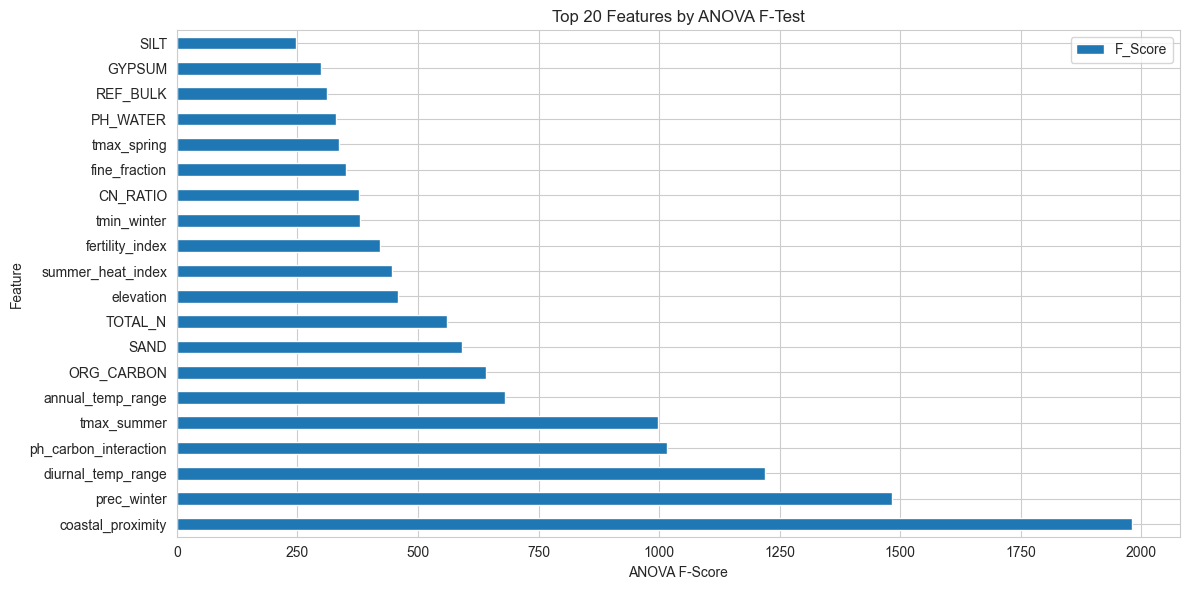

In [11]:
print("="*80)
print("STEP 3: APPLY ADDITIONAL METHODS TO NARROW TO TOP 20")
print("="*80)

print("\n📊 Method 1: ANOVA F-Test")
print("-" * 80)

# ANOVA F-test for the 30 selected features
selector_anova = SelectKBest(f_classif, k='all')
selector_anova.fit(numerical_X_selected, y)

# Get scores
anova_scores = pd.DataFrame({
    'Feature': numerical_X_selected.columns,
    'F_Score': selector_anova.scores_,
    'P_Value': selector_anova.pvalues_
}).sort_values('F_Score', ascending=False)

print("\nTop 20 features by ANOVA F-Score:\n")
for i, row in enumerate(anova_scores.head(20).itertuples(), 1):
    print(f"  {i:2d}. {row.Feature:45s} | F-Score = {row.F_Score:8.2f}")

# Visualize
plt.figure(figsize=(10, 8))
anova_scores.head(20).plot(x='Feature', y='F_Score', kind='barh')
plt.xlabel('ANOVA F-Score')
plt.title('Top 20 Features by ANOVA F-Test')
plt.tight_layout()
plt.show()


📊 Method 2: Mutual Information
--------------------------------------------------------------------------------

Top 20 features by Mutual Information:

   1. prec_winter                                   | MI-Score = 0.3146
   2. diurnal_temp_range                            | MI-Score = 0.2977
   3. annual_temp_range                             | MI-Score = 0.2872
   4. summer_heat_index                             | MI-Score = 0.2707
   5. coastal_proximity                             | MI-Score = 0.2360
   6. tmax_summer                                   | MI-Score = 0.2081
   7. tmin_winter                                   | MI-Score = 0.1605
   8. tmin_summer                                   | MI-Score = 0.1579
   9. tmax_spring                                   | MI-Score = 0.1554
  10. lat_long_interaction                          | MI-Score = 0.1476
  11. fertility_index                               | MI-Score = 0.1163
  12. nutrient_availability                         | 

<Figure size 1000x800 with 0 Axes>

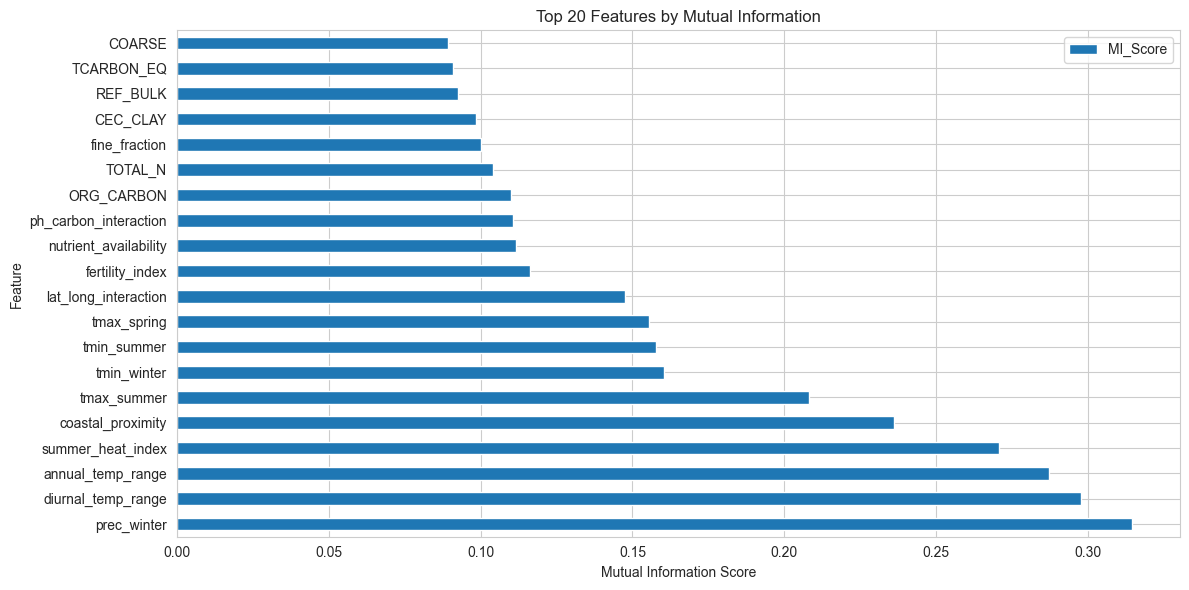

In [12]:
print("\n📊 Method 2: Mutual Information")
print("-" * 80)

# Mutual Information for the 30 selected features
mi_scores = mutual_info_classif(numerical_X_selected, y, random_state=42)
mi_scores_df = pd.DataFrame({
    'Feature': numerical_X_selected.columns,
    'MI_Score': mi_scores
}).sort_values('MI_Score', ascending=False)

print("\nTop 20 features by Mutual Information:\n")
for i, row in enumerate(mi_scores_df.head(20).itertuples(), 1):
    print(f"  {i:2d}. {row.Feature:45s} | MI-Score = {row.MI_Score:.4f}")

# Visualize
plt.figure(figsize=(10, 8))
mi_scores_df.head(20).plot(x='Feature', y='MI_Score', kind='barh')
plt.xlabel('Mutual Information Score')
plt.title('Top 20 Features by Mutual Information')
plt.tight_layout()
plt.show()

### 3.3 Feature Importance from Random Forest


📊 Method 3: Random Forest Feature Importance
--------------------------------------------------------------------------------

Top 20 features by Random Forest Importance:

   1. coastal_proximity                             | Importance = 0.1480
   2. prec_winter                                   | Importance = 0.0839
   3. lat_long_interaction                          | Importance = 0.0788
   4. elevation                                     | Importance = 0.0685
   5. tmax_summer                                   | Importance = 0.0656
   6. diurnal_temp_range                            | Importance = 0.0632
   7. annual_temp_range                             | Importance = 0.0539
   8. tmin_winter                                   | Importance = 0.0538
   9. summer_heat_index                             | Importance = 0.0507
  10. roughness                                     | Importance = 0.0478
  11. tmin_summer                                   | Importance = 0.0450
  12. terrai

<Figure size 1000x800 with 0 Axes>

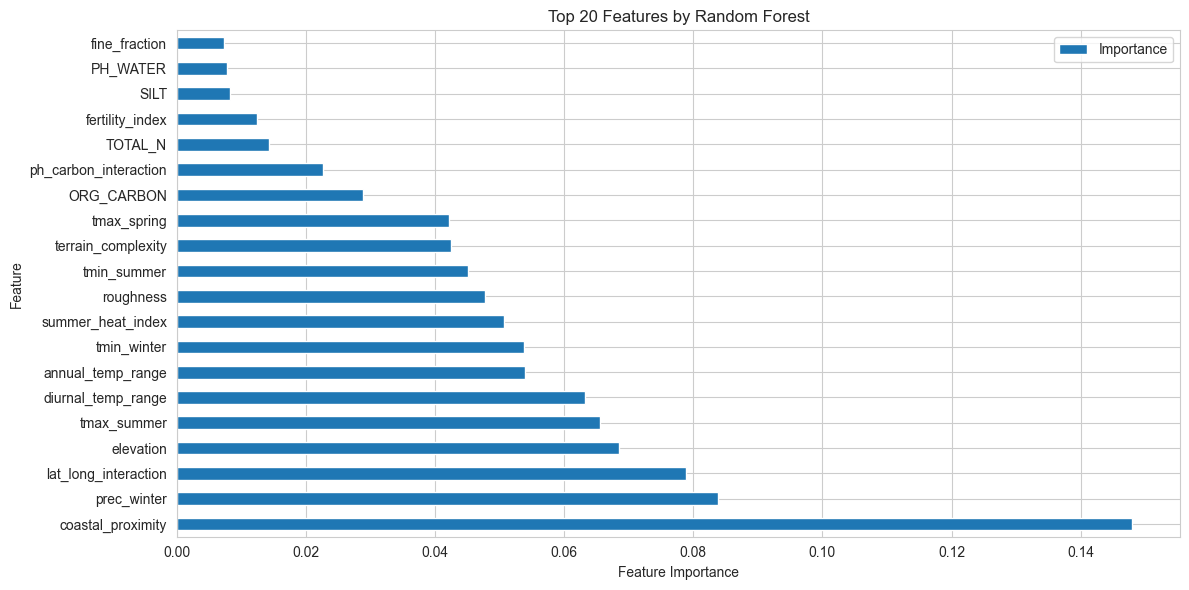

In [13]:
print("\n📊 Method 3: Random Forest Feature Importance")
print("-" * 80)

# Train Random Forest on the 30 selected features
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(numerical_X_selected, y)

# Get feature importances
feature_importance = pd.DataFrame({
    'Feature': numerical_X_selected.columns,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 20 features by Random Forest Importance:\n")
for i, row in enumerate(feature_importance.head(20).itertuples(), 1):
    print(f"  {i:2d}. {row.Feature:45s} | Importance = {row.Importance:.4f}")

# Visualize
plt.figure(figsize=(10, 8))
feature_importance.head(20).plot(x='Feature', y='Importance', kind='barh')
plt.xlabel('Feature Importance')
plt.title('Top 20 Features by Random Forest')
plt.tight_layout()
plt.show()

### 3.4 Combine Methods and Select Final Top 20 Features

In [14]:
print("="*80)
print("STEP 4: COMBINE ALL METHODS AND SELECT FINAL TOP 20")
print("="*80)

# Normalize scores to 0-1 range
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# Create a comprehensive scoring dataframe for the 30 features
feature_scores = pd.DataFrame({'Feature': numerical_X_selected.columns})

# Add target correlation scores (already computed)
correlation_scores = target_corr_reduced[numerical_X_selected.columns].reset_index()
correlation_scores.columns = ['Feature', 'Correlation']
feature_scores = feature_scores.merge(correlation_scores, on='Feature', how='left')

# Add ANOVA scores
feature_scores = feature_scores.merge(
    anova_scores[['Feature', 'F_Score']],
    on='Feature', how='left'
)

# Add MI scores
feature_scores = feature_scores.merge(
    mi_scores_df,
    on='Feature', how='left'
)

# Add RF importance
feature_scores = feature_scores.merge(
    feature_importance[['Feature', 'Importance']],
    on='Feature', how='left'
)

# Fill NaN values with 0
feature_scores = feature_scores.fillna(0)

# Normalize each score
for col in ['Correlation', 'F_Score', 'MI_Score', 'Importance']:
    if feature_scores[col].max() > 0:
        feature_scores[f'{col}_norm'] = scaler.fit_transform(feature_scores[[col]])
    else:
        feature_scores[f'{col}_norm'] = 0

# Calculate composite score (average of normalized scores)
feature_scores['Composite_Score'] = feature_scores[
    ['Correlation_norm', 'F_Score_norm', 'MI_Score_norm', 'Importance_norm']
].mean(axis=1)

# Sort by composite score
feature_scores = feature_scores.sort_values('Composite_Score', ascending=False)

print("\nTop 20 features by composite score:\n")
print(f"{'Rank':<6} {'Feature':<45} {'Composite':<12} {'Corr':<8} {'F-Score':<10} {'MI':<8} {'RF Imp':<8}")
print("-" * 105)
for i, row in enumerate(feature_scores.head(20).itertuples(), 1):
    print(f"{i:<6} {row.Feature:<45} {row.Composite_Score:.4f}      {row.Correlation:.4f}   {row.F_Score:8.1f}   {row.MI_Score:.4f}   {row.Importance:.4f}")

print(f"\n{'='*80}")
print(f"✅ Final Feature Selection Complete")
print(f"{'='*80}")

STEP 4: COMBINE ALL METHODS AND SELECT FINAL TOP 20

Top 20 features by composite score:

Rank   Feature                                       Composite    Corr     F-Score    MI       RF Imp  
---------------------------------------------------------------------------------------------------------
1      coastal_proximity                             0.9270      0.4814     1981.3   0.2360   0.1480
2      prec_winter                                   0.7837      0.4292     1483.2   0.3146   0.0839
3      diurnal_temp_range                            0.6723      0.3958     1220.2   0.2977   0.0632
4      tmax_summer                                   0.5392      0.3632      998.0   0.2081   0.0656
5      annual_temp_range                             0.5078      0.3065      681.2   0.2872   0.0539
6      summer_heat_index                             0.4153      0.2522      446.1   0.2707   0.0507
7      ph_carbon_interaction                         0.3791      0.3659     1015.5   0.1108   

In [15]:
# Select top 20 features based on composite score
# Note: All features (including one-hot encoded) competed fairly
top_k_final = 20
selected_features = feature_scores['Feature'].head(top_k_final).tolist()

print(f"\n{'='*80}")
print(f"FEATURE SELECTION SUMMARY")
print(f"{'='*80}")
print(f"Original features (before encoding): {len(df_engineered.columns) - 3}")  # Exclude lon, lat, class
print(f"After one-hot encoding: {len(X.columns)}")
print(f"After multicollinearity removal: {len(numerical_X_reduced.columns)}")
print(f"After target correlation selection (top 30): {len(numerical_X_selected.columns)}")
print(f"After composite scoring (final top 20): {len(selected_features)}")
print(f"\nTotal features removed: {len(X.columns) - len(selected_features)}")

# Check if any one-hot encoded features made it to top 20
one_hot_selected = [f for f in selected_features if f.startswith('TEXTURE_SOTER_')]
numerical_selected = [f for f in selected_features if not f.startswith('TEXTURE_SOTER_')]

print(f"\n📋 Final Selected Features ({len(selected_features)}):")
print("-" * 80)
print(f"\nNumerical Features: {len(numerical_selected)}")
for i, feat in enumerate(numerical_selected, 1):
    # Check if it's in top scores
    score_info = feature_scores[feature_scores['Feature'] == feat]
    if not score_info.empty:
        print(f"  {i:2d}. {feat:<45} (Composite Score: {score_info.iloc[0]['Composite_Score']:.4f})")
    else:
        print(f"  {i:2d}. {feat}")

if one_hot_selected:
    print(f"\nOne-Hot Encoded Features: {len(one_hot_selected)}")
    for i, feat in enumerate(one_hot_selected, 1):
        score_info = feature_scores[feature_scores['Feature'] == feat]
        if not score_info.empty:
            print(f"  {i:2d}. {feat:<45} (Composite Score: {score_info.iloc[0]['Composite_Score']:.4f})")
        else:
            print(f"  {i:2d}. {feat}")
    print(f"\n   ✓ One-hot features competed successfully and made it to top 20!")
else:
    print(f"\nOne-Hot Encoded Features: 0")
    print(f"   (None of the one-hot features had high enough predictive power)")

# Create dataset with selected features
X_selected = X[selected_features].copy()
print(f"\n✅ Selected feature set shape: {X_selected.shape}")


FEATURE SELECTION SUMMARY
Original features (before encoding): 63
After one-hot encoding: 63
After multicollinearity removal: 52
After target correlation selection (top 30): 30
After composite scoring (final top 20): 20

Total features removed: 43

📋 Final Selected Features (20):
--------------------------------------------------------------------------------

Numerical Features: 20
   1. coastal_proximity                             (Composite Score: 0.9270)
   2. prec_winter                                   (Composite Score: 0.7837)
   3. diurnal_temp_range                            (Composite Score: 0.6723)
   4. tmax_summer                                   (Composite Score: 0.5392)
   5. annual_temp_range                             (Composite Score: 0.5078)
   6. summer_heat_index                             (Composite Score: 0.4153)
   7. ph_carbon_interaction                         (Composite Score: 0.3791)
   8. tmin_winter                                   (Composite Scor

## 4. Feature Scaling

Normalize numerical features to ensure they have similar scales.

**Note**: Categorical feature (TEXTURE_SOTER) was already one-hot encoded in Section 3, so all features are now numerical and ready for scaling.

In [16]:
# Verify all selected features are numerical
print("="*80)
print("FEATURE TYPE VERIFICATION")
print("="*80)

print(f"\nSelected features ({len(X_selected.columns)}):")
print(f"  Total: {X_selected.shape[1]}")
print(f"  All numerical: {all(X_selected.dtypes != 'object')}")

# Show data types
print(f"\nData types:")
dtype_counts = X_selected.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count} features")

# Check for one-hot encoded features in selected set
one_hot_in_selected = [col for col in X_selected.columns if col.startswith('TEXTURE_SOTER_')]
if one_hot_in_selected:
    print(f"\n✓ One-hot encoded features in final selection:")
    for col in one_hot_in_selected:
        unique_vals = X_selected[col].unique()
        print(f"  {col}: {unique_vals} (binary)")
else:
    print(f"\n✗ No one-hot encoded features in final selection")

print(f"\n✓ All features are numerical and ready for scaling!")
print("="*80)

FEATURE TYPE VERIFICATION

Selected features (20):
  Total: 20
  All numerical: True

Data types:
  float64: 20 features

✗ No one-hot encoded features in final selection

✓ All features are numerical and ready for scaling!


In [17]:
# Check feature distributions before scaling
print("="*80)
print("FEATURE STATISTICS BEFORE SCALING")
print("="*80)

print("\nSample statistics for first 5 features:")
print(X_selected.describe().T[['mean', 'std', 'min', 'max']].head())

# Check one-hot encoded features (should be binary 0/1)
one_hot_in_selected = [col for col in X_selected.columns if col.startswith('TEXTURE_SOTER_')]
if one_hot_in_selected:
    print(f"\nOne-hot encoded features (binary, no scaling needed):")
    for col in one_hot_in_selected:
        print(f"  {col}: min={X_selected[col].min()}, max={X_selected[col].max()}, unique values={X_selected[col].nunique()}")

print("\n✓ Ready for scaling!")
print("="*80)

FEATURE STATISTICS BEFORE SCALING

Sample statistics for first 5 features:
                            mean       std       min       max
coastal_proximity   1.596685e+00  1.177746 -0.323460  3.999740
prec_winter         8.327518e-17  1.000076 -1.186831  3.121848
diurnal_temp_range  3.276932e-16  0.487626 -2.042776  1.114530
tmax_summer         6.034747e-16  1.000076 -2.344804  2.412565
annual_temp_range   9.067655e-01  0.652125 -0.711875  3.033624

✓ Ready for scaling!


### 4.1 Apply StandardScaler

Normalize all features (including one-hot encoded binary features) using Z-score normalization.

In [18]:
# Apply StandardScaler (Z-score normalization)
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X_selected),
    columns=X_selected.columns,
    index=X_selected.index
)

print("="*80)
print("FEATURE SCALING COMPLETE")
print("="*80)

print("\nFeature statistics after scaling:\n")
print(X_scaled.describe().T[['mean', 'std', 'min', 'max']].head(10))

print(f"\n{'='*80}")
print(f"Feature Scaling Summary")
print(f"{'='*80}")
print(f"Scaling method: StandardScaler (Z-score normalization)")
print(f"Features scaled: {X_scaled.shape[1]}")
print(f"All features now have mean ≈ 0 and std ≈ 1")

# Note about one-hot encoded features
one_hot_in_scaled = [col for col in X_scaled.columns if col.startswith('TEXTURE_SOTER_')]
if one_hot_in_scaled:
    print(f"\nNote: One-hot encoded features also scaled:")
    for col in one_hot_in_scaled:
        print(f"  {col}: mean={X_scaled[col].mean():.4f}, std={X_scaled[col].std():.4f}")
    print(f"  (Binary 0/1 values normalized to z-scores for consistency)")

print("="*80)

FEATURE SCALING COMPLETE

Feature statistics after scaling:

                               mean       std       min       max
coastal_proximity      1.665504e-16  1.000076 -1.630480  2.040541
prec_winter            1.838543e-17  1.000076 -1.186831  3.121848
diurnal_temp_range     4.325983e-18  1.000076 -4.189545  2.285798
tmax_summer            1.081496e-17  1.000076 -2.344804  2.412565
annual_temp_range     -1.543835e-16  1.000076 -2.482292  3.261677
summer_heat_index      1.189645e-17  1.000076 -2.410634  2.358827
ph_carbon_interaction  1.081496e-18  1.000076 -2.524752  5.346492
tmin_winter            3.893385e-17  1.000076 -2.951007  2.323271
ORG_CARBON            -7.840844e-17  1.000076 -1.682529  6.195392
tmax_spring           -2.162992e-18  1.000076 -2.572816  2.480341

Feature Scaling Summary
Scaling method: StandardScaler (Z-score normalization)
Features scaled: 20
All features now have mean ≈ 0 and std ≈ 1


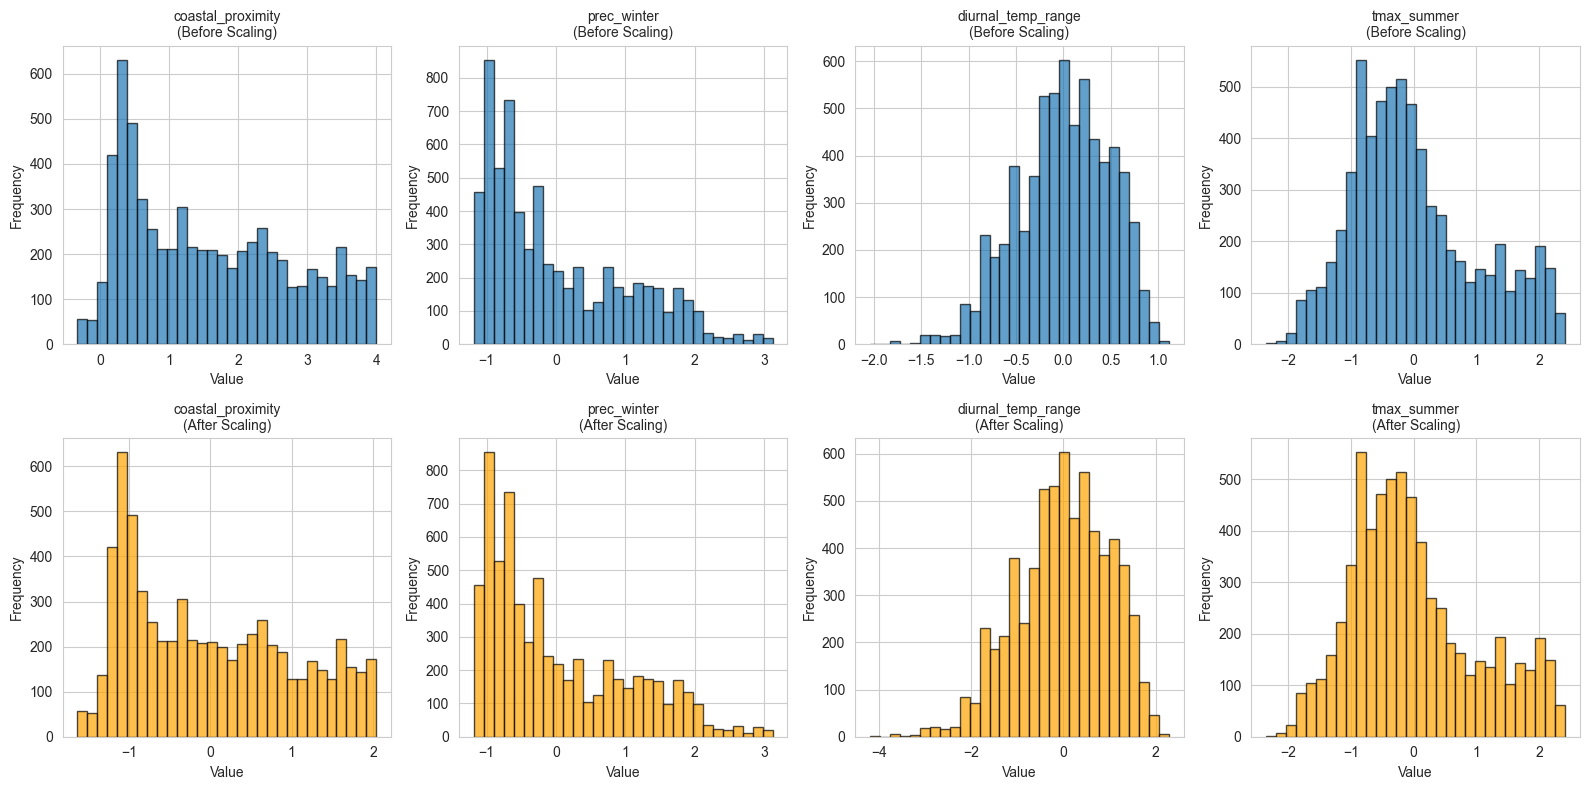

In [19]:
# Visualize distribution of a few features before and after scaling
sample_features = X_selected.columns[:4].tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for idx, feature in enumerate(sample_features):
    # Before scaling
    axes[0, idx].hist(X_selected[feature], bins=30, edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'{feature}\n(Before Scaling)', fontsize=10)
    axes[0, idx].set_xlabel('Value')
    axes[0, idx].set_ylabel('Frequency')
    
    # After scaling
    axes[1, idx].hist(X_scaled[feature], bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[1, idx].set_title(f'{feature}\n(After Scaling)', fontsize=10)
    axes[1, idx].set_xlabel('Value')
    axes[1, idx].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 5. Final Dataset Preparation

In [20]:
# Combine features with target and coordinates
final_dataset = pd.concat([
    df_engineered[['longitude', 'latitude', 'class']],
    X_scaled
], axis=1)

print(f"Final dataset shape: {final_dataset.shape}")
print(f"\nFeatures: {final_dataset.columns.tolist()[:10]} ... (showing first 10)")
print(f"\nClass distribution:")
print(final_dataset['class'].value_counts())
print(f"\nMissing values: {final_dataset.isnull().sum().sum()}")

Final dataset shape: (6570, 23)

Features: ['longitude', 'latitude', 'class', 'coastal_proximity', 'prec_winter', 'diurnal_temp_range', 'tmax_summer', 'annual_temp_range', 'summer_heat_index', 'ph_carbon_interaction'] ... (showing first 10)

Class distribution:
class
0    3285
1    3285
Name: count, dtype: int64

Missing values: 0


In [21]:
# Display sample of final dataset
print("Sample of final engineered dataset:\n")
final_dataset.head(10)

Sample of final engineered dataset:



,longitude,latitude,class,coastal_proximity,prec_winter,diurnal_temp_range,tmax_summer,annual_temp_range,summer_heat_index,ph_carbon_interaction,tmin_winter,ORG_CARBON,tmax_spring,elevation,lat_long_interaction,TOTAL_N,tmin_summer,SAND,fertility_index,roughness,fine_fraction,REF_BULK,terrain_complexity
0,9.23018,35.09261,0,0.263834,-0.655354,0.401039,0.896943,-0.760563,0.226101,0.316687,0.574852,-0.479530,0.886839,-0.162125,1.114065,-0.244059,0.608851,1.544961,-0.052968,-0.662360,-1.059602,-0.777567,-0.376711
1,5.60547,33.50662,0,1.610568,-1.068579,0.802907,2.112599,1.282442,2.026498,-0.936466,0.531323,-0.669719,2.274337,-0.887919,-0.019828,-0.760385,2.133825,0.894204,0.509886,-0.714202,-0.622151,-0.893355,-0.354981
2,11.11005,33.48151,1,1.631890,-1.186831,1.111404,-0.197673,2.150991,0.985127,1.335505,-2.283561,-1.673363,-0.125004,-1.178717,1.514580,-2.666820,-0.239723,0.243448,4.064224,-0.741074,-4.011642,-0.545994,-0.277175
3,7.48122,36.53608,0,-0.961881,1.170592,-0.513859,-0.676567,-0.594130,-0.736541,0.786645,0.364461,0.400377,-0.627896,-0.265467,0.692666,0.510571,-0.682457,-1.058065,-0.812686,0.329142,1.028867,0.843445,-0.411544
4,4.54391,36.71546,1,-1.114200,1.901567,-1.740076,-1.565943,-2.115129,-1.518104,0.786645,-0.433573,0.400377,-1.621562,0.914549,-0.194703,0.510571,-0.799290,-1.058065,-0.812686,2.320253,1.028867,0.843445,3.079746
5,4.86043,36.09051,1,-0.583528,-0.348218,-0.130643,-0.034533,-0.033202,-0.442526,-0.469337,-0.919648,-0.360376,-0.767252,1.193330,-0.123185,-0.244059,-0.313512,-0.515768,-0.125492,-0.044949,0.725899,1.190804,-0.680444
6,4.07055,34.12395,0,1.086366,-0.987793,0.881841,1.265324,1.103527,1.139749,-0.936466,-0.361024,-0.669719,1.092843,0.092624,-0.427400,-0.760385,1.100779,0.894204,0.509886,-0.522840,-0.622151,-0.893355,-0.445373
7,8.61479,36.75546,1,-1.148166,2.461446,-1.059646,-1.087048,-0.465400,-1.110145,1.446775,0.524068,1.312364,-0.785428,-0.678832,1.053488,1.662375,-0.596370,-0.081931,-0.785629,0.530853,0.095602,-0.545994,-0.840143
8,3.24131,36.73895,1,-1.134147,0.625402,-0.119547,-0.902858,0.942432,-0.382745,0.786645,0.850536,0.400377,-0.015943,-1.154684,-0.592545,0.510571,-0.393450,-1.058065,-0.812686,-0.807483,1.028867,0.843445,-0.214974
9,-0.56537,34.28301,0,0.951301,-0.736197,1.299033,0.149657,0.785376,-0.578199,-0.943387,-1.253372,-0.674302,-0.106827,1.539404,-1.746219,-0.283777,-0.442643,-0.081931,0.100069,-0.612031,0.095602,-0.545994,-0.432458


In [22]:
# Save the engineered dataset
output_path = FIRES_ENGINEERED_SUPERVISED
output_path.parent.mkdir(parents=True, exist_ok=True)
final_dataset.to_csv(output_path, index=False)
print(f"✅ Engineered dataset saved to: {output_path}")

✅ Engineered dataset saved to: C:\Users\Azur\Downloads\TP\DM\results\features\supervised\fires_engineered_features.csv


In [23]:
# Save feature importance and selection results
feature_scores.to_csv(FEATURE_IMPORTANCE_SUPERVISED, index=False)
print(f"✅ Feature importance scores saved to: {FEATURE_IMPORTANCE_SUPERVISED}")

# Save selected features list
with open(SELECTED_FEATURES_SUPERVISED, 'w') as f:
    f.write("Selected Features for Model Training\n")
    f.write("="*50 + "\n\n")
    for i, feat in enumerate(selected_features, 1):
        f.write(f"{i}. {feat}\n")
print(f"✅ Selected features list saved to: {SELECTED_FEATURES_SUPERVISED}")

✅ Feature importance scores saved to: C:\Users\Azur\Downloads\TP\DM\results\features\supervised\feature_importance_scores.csv
✅ Selected features list saved to: C:\Users\Azur\Downloads\TP\DM\results\features\supervised\selected_features.txt


## 6. Summary

### Feature Engineering Pipeline Summary

**1. Feature Extraction:**
- Created 22 new features from domain knowledge
- Climate features: temperature ranges, precipitation patterns, drought indices
- Topography features: terrain complexity, aspect categories, slope interactions
- Soil features: composition ratios, fertility indices, moisture retention
- Spatial features: country indicators, coastal proximity

**2. Categorical Feature Encoding:**
- **TEXTURE_USDA**: Already numerical (normalized values) - treated as numerical
- **TEXTURE_SOTER**: One-hot encoded into binary columns
  - TEXTURE_SOTER_F (Fine texture indicator)
  - TEXTURE_SOTER_M (Medium texture indicator)
  - Baseline: TEXTURE_SOTER_C (Coarse texture, when both = 0)
  - Note: `drop_first=True` drops the first category alphabetically (C in this case)
- One-hot encoded features competed fairly with all numerical features

**3. Feature Selection (Multi-Step Process):**

**Step 1: One-Hot Encoding**
- Applied early to allow categorical features to participate in selection
- Created binary columns that can be correlated with target

**Step 2: Remove Multicollinearity (Feature-to-Feature)**
- Identified highly correlated feature pairs (correlation > 0.90)
- For each pair, kept the feature with higher target correlation
- Removed redundant features to reduce multicollinearity
- One-hot encoded features included in this analysis

**Step 3: Select Top 30 by Target Correlation**
- Calculated correlation between ALL features (including one-hot) and target
- Selected top 30 features with highest absolute correlation to fire occurrence
- One-hot encoded features competed on equal footing

**Step 4: Narrow to Top 20 with Additional Methods**
- Applied ANOVA F-test for statistical significance
- Applied Mutual Information for non-linear relationships
- Applied Random Forest for feature importance
- Combined all methods with composite scoring
- Selected final top 20 features (may include one-hot encoded features if they scored high)

**4. Feature Scaling:**
- Applied StandardScaler for Z-score normalization
- All features now have mean ≈ 0 and standard deviation ≈ 1
- Ensures fair comparison and better model performance
- One-hot encoded features also scaled for consistency

**Final Output:**
- Engineered dataset: rows × 23 columns (longitude, latitude, class + 20 selected features)
- Ready for machine learning model training
- All features scaled and properly encoded
- No missing values
- No multicollinearity issues
- One-hot encoded features competed fairly in selection process

In [24]:
print("\n" + "="*80)
print("FEATURE ENGINEERING COMPLETE")
print("="*80)
print(f"\n📊 Original dataset: {df.shape[0]} rows × {df.shape[1]} features")
print(f"📊 Final dataset: {final_dataset.shape[0]} rows × {final_dataset.shape[1]} columns")
print(f"\n✅ Feature Extraction: Created 22 new domain-specific features")
print(f"✅ Categorical Encoding: One-hot encoded TEXTURE_SOTER (created binary features)")
print(f"✅ Feature Selection: Selected top {len(selected_features)} most predictive features")
print(f"     - Multicollinearity removal (r > 0.90)")
print(f"     - Target correlation ranking (top 30)")
print(f"     - Composite scoring: ANOVA + MI + RF (top 20)")

# Check if one-hot features made it to final selection
one_hot_final = [col for col in selected_features if col.startswith('TEXTURE_SOTER_')]
if one_hot_final:
    print(f"✅ One-hot features in final selection: {one_hot_final}")
    print(f"     (Categorical feature competed successfully!)")
else:
    print(f"✅ No one-hot features in final selection")
    print(f"     (Categorical feature had lower predictive power)")

print(f"✅ Feature Scaling: StandardScaler applied (all features normalized)")
print(f"\n📁 Output file: {output_path}")
print(f"\n🎯 Dataset is ready for model training!")
print("="*80)


FEATURE ENGINEERING COMPLETE

📊 Original dataset: 6570 rows × 44 features
📊 Final dataset: 6570 rows × 23 columns

✅ Feature Extraction: Created 22 new domain-specific features
✅ Categorical Encoding: One-hot encoded TEXTURE_SOTER (created binary features)
✅ Feature Selection: Selected top 20 most predictive features
     - Multicollinearity removal (r > 0.90)
     - Target correlation ranking (top 30)
     - Composite scoring: ANOVA + MI + RF (top 20)
✅ No one-hot features in final selection
     (Categorical feature had lower predictive power)
✅ Feature Scaling: StandardScaler applied (all features normalized)

📁 Output file: C:\Users\Azur\Downloads\TP\DM\results\features\supervised\fires_engineered_features.csv

🎯 Dataset is ready for model training!
